# Cycle respiratoire du réseau (Plasticité ↔ Stabilité)

On construit un système qui **gèle et crée des couches dynamiquement** pour être plus stable.

**Signal d'Activité Structurelle** :
$$S(t) = \text{Taux de Création}(t) - \text{Taux d'Élagage}(t)$$

L'analyse **fréquentielle (FFT)** de $S(t)$ détecte :
- **Signal plat / bruit blanc** → stabilité (réorganisation saine)
- **Pic fréquentiel net (cycle limite)** → instabilité structurelle → déclenche les leviers

Quand l'oscillation apparaît : **spawning de couche** (gel C1 + création C2).
Le **dégel** se fait par **pic de surprise incompressible** (changement d'environnement) + **plasticité sélective** (η(S)).

## 0. Imports

In [1]:
# Cycle respiratoire : gel dynamique + création de couches
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from recherche_agi import (load_mnist, AnchorNeurons, dynamic_k,
                           RespiratoryController, StructuralActivitySignal)

# charger les données (utilisées dans les sections suivantes)
train_set, test_set = load_mnist()


## 1. Signal d'Activité Structurelle + détection d'oscillation (FFT)

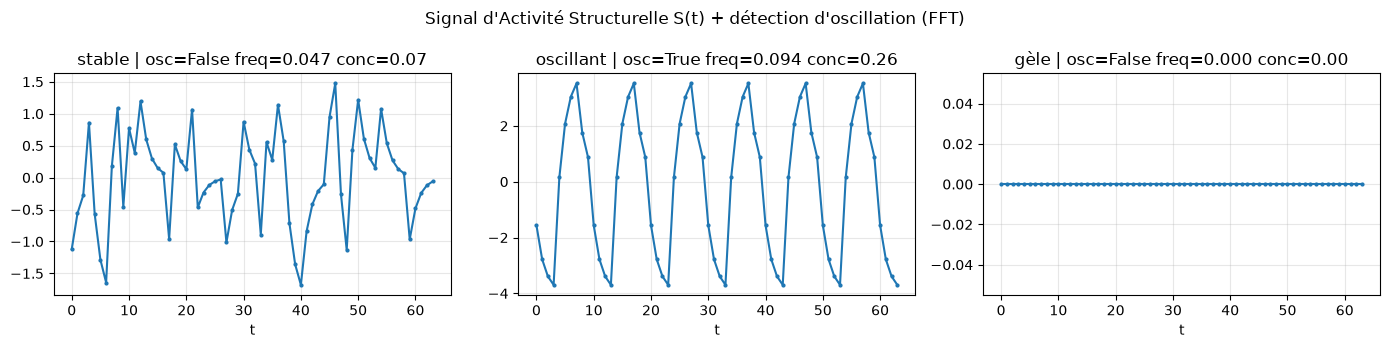

La FFT distingue : stable (aucun pic), oscillant (pic net = cycle limite),
gèle (énergie 0). Le pic net déclenche les leviers architecturaux.


In [2]:
# Générer 3 signaux : stable, oscillant (cycle limite), gelé
rng = np.random.default_rng(0)

def run_signal(mode, n=200):
    sig = StructuralActivitySignal(window=64, sample_every=1)
    for t in range(n):
        if mode=='stable':
            sig.event_create(rng.integers(0,2)); sig.event_prune(rng.integers(0,2))
        elif mode=='oscillant':
            if (t%10)<4: sig.event_create(2)
            if (t%10)>=6: sig.event_prune(2)
        # 'gèle' : aucun événement
        sig.tick()
    return sig.samples, sig.detect_oscillation()

labels = ['stable', 'oscillant', 'gèle']
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, mode in zip(axes, labels):
    samples, r = run_signal(mode)
    ax.plot(samples, 'o-', markersize=2)
    ax.set_title(f"{mode} | osc={r['oscillating']} freq={r['dominant_freq'] if r['dominant_freq'] is not None else 0:.3f} conc={r['spectral_concentration']:.2f}")
    ax.set_xlabel("t"); ax.grid(alpha=0.3)
plt.suptitle("Signal d'Activité Structurelle S(t) + détection d'oscillation (FFT)")
plt.tight_layout(); plt.show()

print("La FFT distingue : stable (aucun pic), oscillant (pic net = cycle limite),")
print("gèle (énergie 0). Le pic net déclenche les leviers architecturaux.")

## 2. Cycle respiratoire : exploration → consolidation (spawning) → perturbation (dégel)

In [3]:
ctrl = RespiratoryController(surprise_unfreeze=0.8, unfreeze_streak=5, base_lr=0.1)
W1 = np.random.default_rng(0).normal(0, 0.1, (80, 784))
events = []

# --- Phase Exploration : C1 se forme, activité modérée (bruit) ---
for t in range(100):
    ctrl.record_create(1 if t%7==0 else 0)
    ctrl.record_prune(1 if t%11==0 else 0)
    ctrl.tick()
events.append(('exploration', ctrl.summary()['phase'], ctrl.frozen, ctrl.layer_count))

# --- Phase Oscillation (cycle limite) -> consolidation / spawning ---
for t in range(120):
    if (t%10)<4: ctrl.record_create(2)
    if (t%10)>=6: ctrl.record_prune(2)
    ctrl.tick()
osc = ctrl.signal.detect_oscillation()['oscillating']
ctrl.spawn_layer()   # levier 3 : gel C1 + création C2
events.append(('oscillation', 'consolidation', ctrl.frozen, ctrl.layer_count))

# --- Phase Perturbation : objet inconnu -> dégel par surprise ---
unfroze = False
for t in range(8):
    x = rng.random(784)  # objet inconnu
    S = ctrl.reconstruction_surprise(x, W1)
    lr = ctrl.effective_lr(S)
    if ctrl.check_unfreeze(S):
        ctrl.unfreeze_extension(); unfroze = True; break
events.append(('perturbation', 'dégel', ctrl.frozen, ctrl.layer_count))

print("=== Journal du cycle respiratoire ===")
for name, phase, frozen, layers in events:
    print(f"  {name:12s}: phase={phase}, C1 gelée={frozen}, couches={layers}")
print(f"  Oscillation détectée : {osc}")
print(f"  Dégel par surprise : {unfroze}")
print(f"\nÉvénements du contrôleur :")
for e in ctrl.log:
    print(f"  - {e}")

=== Journal du cycle respiratoire ===
  exploration : phase=exploration, C1 gelée=False, couches=1
  oscillation : phase=consolidation, C1 gelée=True, couches=2
  perturbation: phase=dégel, C1 gelée=False, couches=2
  Oscillation détectée : False
  Dégel par surprise : True

Événements du contrôleur :
  - oscillation détectée -> consolidation (gel/spawn)
  - oscillation amortie -> stabilisation
  - oscillation détectée -> consolidation (gel/spawn)
  - oscillation amortie -> stabilisation
  - spawning : couche 2 créée, C1 gelée
  - dégel : neurogenèse d'extension activée


## 3. Surprise de reconstruction : connu vs inconnu (déclencheur de dégel)

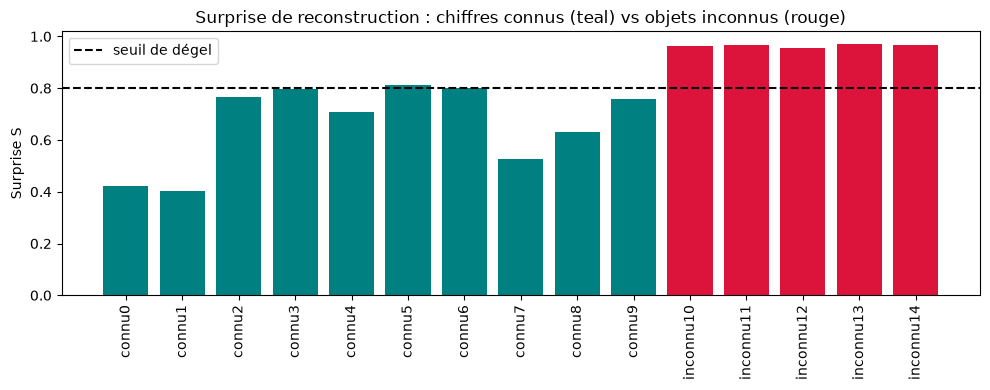

  Connus : 0.66
  Inconnus : 0.96
=> La surprise discrimine : les connus (< seuil) restent gelés, les
   inconnus (> seuil, persistant) déclenchent le dégel sélectif.


In [4]:
# W1 entraîné sur MNIST -> les connus ont une surprise FAIBLE, les inconnus ÉLEVÉE
layer1 = AnchorNeurons(d_in=784, n_neurons=80, seed=0, lr=0.1, use_homeostasis=True)
def latent(img_np):
    img=img_np.flatten(); n=np.linalg.norm(img); return img if n<1e-6 else img/n
cnt=[0]*10
for i in range(len(train_set)):
    l=int(train_set[i][1])
    if l>1 or cnt[l]>=60: continue
    layer1.learn(latent(train_set[i][0].squeeze().numpy()), k=dynamic_k(0.5,1,5), label=l); cnt[l]+=1
    if sum(cnt[:2])>=120: break
for d in range(2,10):
    shown=0
    for i in range(len(train_set)):
        l=int(train_set[i][1])
        if l!=d: continue
        layer1.learn(latent(train_set[i][0].squeeze().numpy()), k=dynamic_k(0.5,1,5), label=l); shown+=1
        if shown>=40: break
W1 = layer1.W

ctrl2 = RespiratoryController(surprise_unfreeze=0.8, unfreeze_streak=5)
surprises = []
for d in range(10):
    img=next(test_set[i][0].squeeze().numpy() for i in range(len(test_set)) if int(test_set[i][1])==d)
    surprises.append(('connu', ctrl2.reconstruction_surprise(latent(img), W1)))
for seed in range(5):
    surprises.append(('inconnu', ctrl2.reconstruction_surprise(rng.random(784), W1)))

# bar chart
names = [f"{t}{i}" for i,(t,_) in enumerate(surprises)]
vals = [s for _,s in surprises]
colors = ['teal' if t=='connu' else 'crimson' for t,_ in surprises]
plt.figure(figsize=(10,4))
plt.bar(names, vals, color=colors)
plt.axhline(0.8, color='black', ls='--', label='seuil de dégel')
plt.xticks(rotation=90); plt.ylabel('Surprise S'); plt.legend()
plt.title("Surprise de reconstruction : chiffres connus (teal) vs objets inconnus (rouge)")
plt.tight_layout(); plt.show()
print(f"  Connus : {np.mean([s for t,s in surprises if t=='connu']):.2f}")
print(f"  Inconnus : {np.mean([s for t,s in surprises if t=='inconnu']):.2f}")
print("=> La surprise discrimine : les connus (< seuil) restent gelés, les")
print("   inconnus (> seuil, persistant) déclenchent le dégel sélectif.")

## 4. Analyse : le cycle respiratoire

In [5]:
print("=== ANALYSE : CYCLE RESPIRATOIRE ===")
print("1. SIGNAL S(t) + FFT : le système détecte l'oscillation (cycle limite) par")
print("   un pic fréquentiel net -> instabilité structurelle.")
print("2. SPAWNING DE COUCHE : l'oscillation ordonne le GEL de C1 + la création")
print("   de C2 (qui agit comme une presse top-down pour stabiliser C1).")
print("3. DÉGEL PAR SURPRISE : un objet inconnu (surprise > seuil, persistant)")
print("   déclenche la PLASTICITÉ SÉLECTIVE : neurogenèse d'extension (W1 gelé,")
print("   ajout de neurones) + métro-plasticité eta(S) par recuit simulé.")
print("4. CYCLE : Exploration (C1 dégelée) -> Consolidation (C1 gelée + C2) ->")
print("   Perturbation (nouveau domaine -> dégel) -> retour à l'exploration.")
print()
print("=> Le réseau 'respire' : il alterne plasticité (explorer) et stabilité")
print("   (consolider), au lieu d'une structure rigide — le compromis de Grossberg.")

=== ANALYSE : CYCLE RESPIRATOIRE ===
1. SIGNAL S(t) + FFT : le système détecte l'oscillation (cycle limite) par
   un pic fréquentiel net -> instabilité structurelle.
2. SPAWNING DE COUCHE : l'oscillation ordonne le GEL de C1 + la création
   de C2 (qui agit comme une presse top-down pour stabiliser C1).
3. DÉGEL PAR SURPRISE : un objet inconnu (surprise > seuil, persistant)
   déclenche la PLASTICITÉ SÉLECTIVE : neurogenèse d'extension (W1 gelé,
   ajout de neurones) + métro-plasticité eta(S) par recuit simulé.
4. CYCLE : Exploration (C1 dégelée) -> Consolidation (C1 gelée + C2) ->
   Perturbation (nouveau domaine -> dégel) -> retour à l'exploration.

=> Le réseau 'respire' : il alterne plasticité (explorer) et stabilité
   (consolider), au lieu d'une structure rigide — le compromis de Grossberg.
